1. Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using matplotlib to visually identify trend and seasonality patterns.



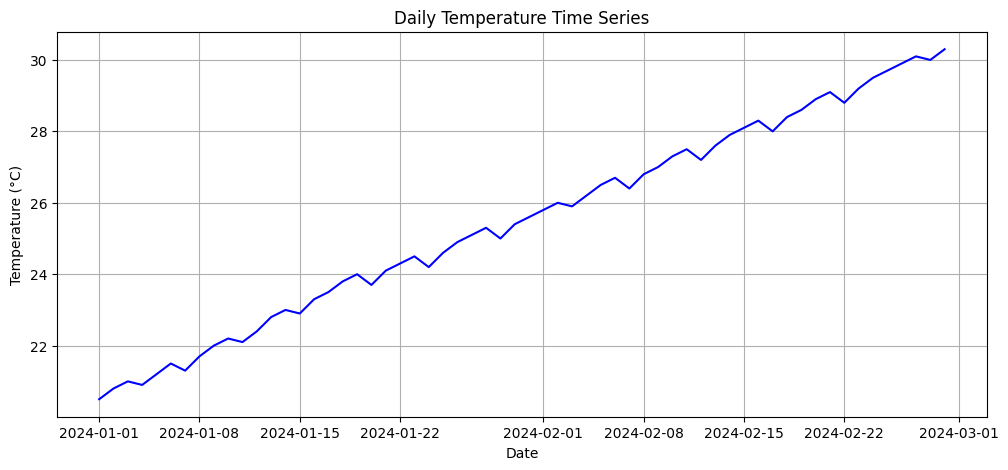

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("temperature.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

plt.figure(figsize=(12,5))
plt.plot(df["Temperature"], color="blue")
plt.title("Daily Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

2. Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the statsmodels seasonal_decompose() function, and plot each component separately.


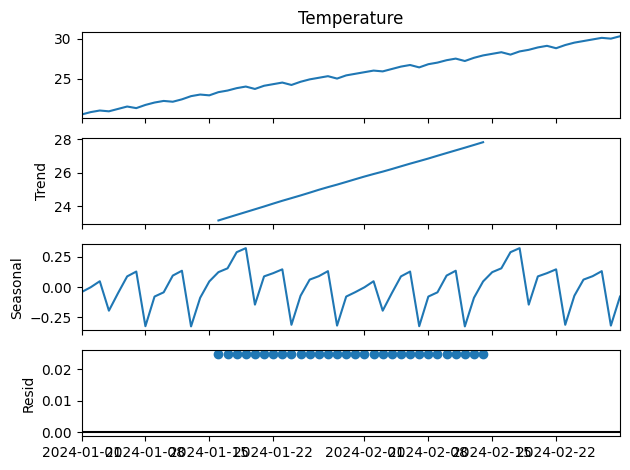

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df["Temperature"],
    model="additive",
    period=30      
)

result.plot()

plt.show()

3. Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from statsmodels.tsa.stattools.adfuller, and print the test statistic and p-value.<br><br><em><strong>Hint:</strong> If the p-value is less than 0.05, the series is likely stationary.</em>


In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Temperature"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("The series is Stationary")
else:
    print("The series is NOT Stationary")

ADF Statistic : -0.7101674475980323
p-value       : 0.8440983326068999
The series is NOT Stationary


4. Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.


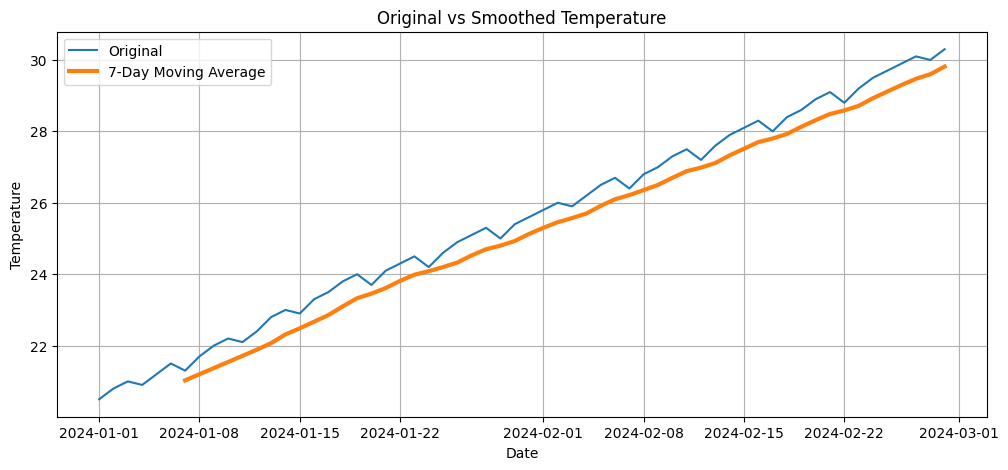

In [4]:

df["Moving_Average"] = df["Temperature"].rolling(window=7).mean()

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df["Temperature"],
    label="Original"
)

plt.plot(
    df.index,
    df["Moving_Average"],
    label="7-Day Moving Average",
    linewidth=3
)

plt.title("Original vs Smoothed Temperature")

plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()

plt.grid(True)

plt.show()

5. Fit an ARIMA model to your temperature data using statsmodels.tsa.arima.model.ARIMA, and forecast the next 7 days. Display the predicted values and plot them along with the original series.<br><br><em><strong>Constraint:</strong> Use (p,d,q) parameters that you determine based on your ADF test and visual analysis.</em>

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Admin

Next 7-Day Forecast:
2024-03-01    30.336072
2024-03-02    30.303083
2024-03-03    30.313028
2024-03-04    30.285731
2024-03-05    30.290807
2024-03-06    30.267810
2024-03-07    30.269225
Freq: D, Name: predicted_mean, dtype: float64


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


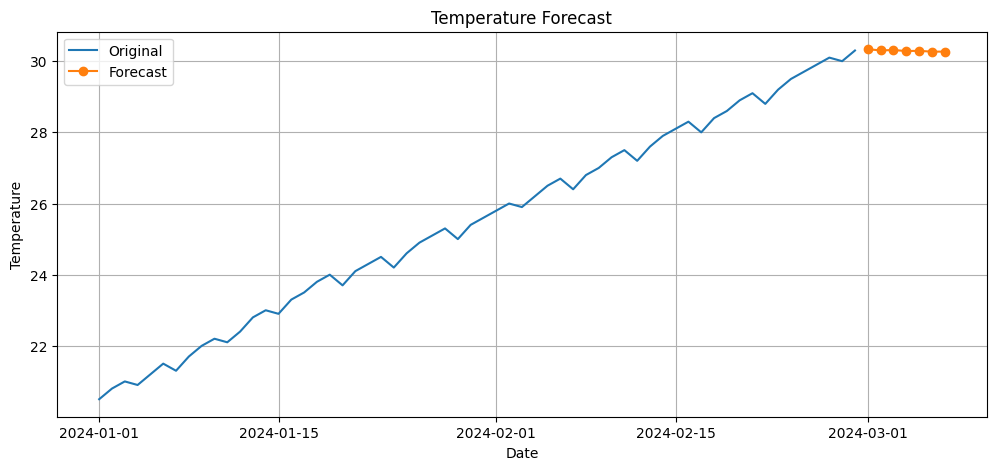

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

model = ARIMA(
    df["Temperature"],
    order=(2,0,2)      
)

model_fit = model.fit()

forecast = model_fit.forecast(steps=7)

print("Next 7-Day Forecast:")

print(forecast)

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df["Temperature"],
    label="Original"
)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=7
)

plt.plot(
    future_dates,
    forecast,
    marker="o",
    label="Forecast"
)

plt.title("Temperature Forecast")

plt.xlabel("Date")
plt.ylabel("Temperature")

plt.legend()

plt.grid(True)

plt.show()